In [18]:
pip install osmnx

Note: you may need to restart the kernel to use updated packages.


In [19]:
# ─────────────────────────────────────────────────────────────
# BLOCO 0 — Instalação (executar uma vez)
# ─────────────────────────────────────────────────────────────
# %pip install osmnx networkx geopandas shapely matplotlib folium scipy

import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from shapely.geometry import Point, MultiPoint, Polygon, MultiPolygon
from shapely.ops import unary_union, voronoi_diagram
from scipy.spatial import Voronoi
import warnings
warnings.filterwarnings('ignore')

In [20]:
# ─────────────────────────────────────────────────────────────
# BLOCO 1 — Configuração
# ─────────────────────────────────────────────────────────────

# Caminho para o ficheiro com os PTD (GeoPackage ou Shapefile)
# Deve ter uma coluna de geometria (pontos) e uma coluna de ID
CAMINHO_PTD     = rCAMINHO_PTD = r"C:\Users\gabri\OneDrive\Ambiente de Trabalho\Final\Voronoi\PTD.shp"
CAMINHO_OUTPUT  = r"C:\Users\gabri\OneDrive\Ambiente de Trabalho\Final\Voronoi"

# Coluna com o ID único do PTD no teu ficheiro
COL_ID_PTD = "id"   # ajustar conforme o teu ficheiro

# Zona de estudo — nome para o OSMnx descarregar a rede de ruas
# Podes usar o nome da cidade ou uma lista de zonas
ZONA_ESTUDO = "Aveiro, Portugal"

# Distância máxima de serviço de cada PTD (metros)
# Para baixa tensão residencial, tipicamente 200-500m de cabo
DISTANCIA_MAX_M = 300

# CRS métrico para Portugal
CRS_METRICO = "EPSG:3763"   # PT-TM06 / ETRS89

print("✓ Configuração carregada.")


✓ Configuração carregada.


In [21]:
# ─────────────────────────────────────────────────────────────
# BLOCO 2 — Carregar os PTD
# ─────────────────────────────────────────────────────────────

print("\nA carregar os PTD...")
gdf_ptd = gpd.read_file(CAMINHO_PTD)

# Garantir CRS geográfico para o OSMnx (precisa de WGS84)
if gdf_ptd.crs is None:
    gdf_ptd = gdf_ptd.set_crs("EPSG:4326")
gdf_ptd_wgs84 = gdf_ptd.to_crs("EPSG:4326")
gdf_ptd_metro = gdf_ptd.to_crs(CRS_METRICO)

print(f"  PTD carregados: {len(gdf_ptd)}")
print(f"  Colunas disponíveis: {gdf_ptd.columns.tolist()}")

# Calcular o bounding box para descarregar só a zona necessária
bbox = gdf_ptd_wgs84.total_bounds   # [minx, miny, maxx, maxy]
print(f"  Área coberta: {bbox}")


A carregar os PTD...
  PTD carregados: 508
  Colunas disponíveis: ['Codigo_de_', 'Distrito', 'Concelho', 'Potencia_i', 'Nivel_de_U', 'Tipo_Const', 'Potencia_C', 'Numero_de_', 'Potencia_G', 'Numero_d_1', 'Histograma', 'CodDistrit', 'CodDistr_1', 'geometry']
  Área coberta: [-8.73948453 40.53326695 -8.52748572 40.69879267]


In [22]:
# ─────────────────────────────────────────────────────────────
# BLOCO 3 — Descarregar a rede de ruas (OSMnx)
# ─────────────────────────────────────────────────────────────

print("\nA descarregar rede de ruas do OpenStreetMap...")
print("  (Pode demorar 1-2 minutos na primeira execução)")

# Descarregar a rede de ruas completa para a zona
# network_type='all' inclui todas as vias (ruas + caminhos + passagens)
# network_type='drive' inclui apenas vias para veículos
G = ox.graph_from_place(
    ZONA_ESTUDO,
    network_type='all',       # 'all' para incluir ruas pedonais (cabos seguem todas as ruas)
    simplify=True,
    retain_all=False,
    truncate_by_edge=True
)

# Converter para não-dirigido (a corrente elétrica pode ir em ambos os sentidos)
G = G.to_undirected()

print(f"  Nós na rede  : {G.number_of_nodes():,}")
print(f"  Arestas      : {G.number_of_edges():,}")

# Opcional: guardar a rede para não ter de descarregar novamente
# ox.save_graphml(G, CAMINHO_OUTPUT + 'rede_ruas_aveiro.graphml')
# G = ox.load_graphml(CAMINHO_OUTPUT + 'rede_ruas_aveiro.graphml')


A descarregar rede de ruas do OpenStreetMap...
  (Pode demorar 1-2 minutos na primeira execução)
  Nós na rede  : 9,934
  Arestas      : 14,007


In [23]:
# ─────────────────────────────────────────────────────────────
# BLOCO 4 — Encontrar o nó da rede mais próximo de cada PTD
# ─────────────────────────────────────────────────────────────

print("\nA mapear cada PTD ao nó de rede mais próximo...")

# OSMnx funciona em WGS84 para este passo
ptd_nos = []
for idx, row in gdf_ptd_wgs84.iterrows():
    lat = row.geometry.y
    lon = row.geometry.x
    # Encontrar o nó da rede de ruas mais próximo de cada PTD
    no_mais_proximo = ox.distance.nearest_nodes(G, X=lon, Y=lat)
    ptd_nos.append({
        'ptd_id'         : row[COL_ID_PTD] if COL_ID_PTD in row else idx,
        'no_rede'        : no_mais_proximo,
        'lat'            : lat,
        'lon'            : lon,
        'geometry_wgs84' : row.geometry
    })

df_ptd_nos = pd.DataFrame(ptd_nos)
print(f"  {len(df_ptd_nos)} PTD mapeados a nós da rede.")


A mapear cada PTD ao nó de rede mais próximo...
  508 PTD mapeados a nós da rede.


In [24]:
# ─────────────────────────────────────────────────────────────
# BLOCO 5 — Algoritmo de Voronoi de Rede
#
# Lógica:
#   Para cada nó da rede de ruas, calcular a distância ao PTD
#   mais próximo (usando Dijkstra de múltiplas origens).
#   O nó é atribuído ao PTD que o alcança com menor distância.
# ─────────────────────────────────────────────────────────────

print("\nA calcular Voronoi de rede (distâncias ao longo das ruas)...")
print("  (Este passo pode demorar vários minutos para redes grandes)")

# Dicionário: nó_rede → (ptd_id, distância)
atribuicao_nos = {}

# Lista dos nós de origem (um por PTD)
nos_ptd    = list(df_ptd_nos['no_rede'])
ids_ptd    = list(df_ptd_nos['ptd_id'])

# Para eficiência, usamos Dijkstra de múltiplas origens
# NetworkX não tem multi-source Dijkstra directo com identificação de origem,
# por isso iteramos — mas podemos optimizar para redes grandes.

# Opção A (mais simples, adequada para < 5000 nós):
# Correr Dijkstra de cada PTD e guardar as distâncias
distancias_por_ptd = {}

for i, (no_ptd, id_ptd) in enumerate(zip(nos_ptd, ids_ptd)):
    print(f"  A calcular distâncias do PTD {i+1}/{len(nos_ptd)} (id={id_ptd})...")
    try:
        # Distâncias de curto-caminho deste PTD a todos os nós
        distancias = nx.single_source_dijkstra_path_length(
            G,
            source=no_ptd,
            cutoff=DISTANCIA_MAX_M,    # Só considerar nós até DISTANCIA_MAX_M metros
            weight='length'            # Usar o comprimento real das ruas em metros
        )
        distancias_por_ptd[id_ptd] = distancias
    except nx.NetworkXError as e:
        print(f"    AVISO: PTD {id_ptd} não acessível — {e}")
        distancias_por_ptd[id_ptd] = {}

# Atribuir cada nó ao PTD mais próximo
print("\n  A atribuir cada nó ao PTD mais próximo...")
for no in G.nodes():
    melhor_ptd  = None
    melhor_dist = float('inf')
    for id_ptd, distancias in distancias_por_ptd.items():
        if no in distancias and distancias[no] < melhor_dist:
            melhor_dist = distancias[no]
            melhor_ptd  = id_ptd
    if melhor_ptd is not None:
        atribuicao_nos[no] = {'ptd_id': melhor_ptd, 'distancia_m': melhor_dist}

print(f"  {len(atribuicao_nos):,} nós atribuídos a PTD.")
nos_sem_ptd = G.number_of_nodes() - len(atribuicao_nos)
if nos_sem_ptd > 0:
    print(f"  {nos_sem_ptd:,} nós sem cobertura (fora do raio de {DISTANCIA_MAX_M}m de qualquer PTD)")


A calcular Voronoi de rede (distâncias ao longo das ruas)...
  (Este passo pode demorar vários minutos para redes grandes)
  A calcular distâncias do PTD 1/508 (id=0)...
  A calcular distâncias do PTD 2/508 (id=1)...
  A calcular distâncias do PTD 3/508 (id=2)...
  A calcular distâncias do PTD 4/508 (id=3)...
  A calcular distâncias do PTD 5/508 (id=4)...
  A calcular distâncias do PTD 6/508 (id=5)...
  A calcular distâncias do PTD 7/508 (id=6)...
  A calcular distâncias do PTD 8/508 (id=7)...
  A calcular distâncias do PTD 9/508 (id=8)...
  A calcular distâncias do PTD 10/508 (id=9)...
  A calcular distâncias do PTD 11/508 (id=10)...
  A calcular distâncias do PTD 12/508 (id=11)...
  A calcular distâncias do PTD 13/508 (id=12)...
  A calcular distâncias do PTD 14/508 (id=13)...
  A calcular distâncias do PTD 15/508 (id=14)...
  A calcular distâncias do PTD 16/508 (id=15)...
  A calcular distâncias do PTD 17/508 (id=16)...
  A calcular distâncias do PTD 18/508 (id=17)...
  A calcular 

In [25]:
# ─────────────────────────────────────────────────────────────
# BLOCO 6 — Construir os polígonos de área de serviço por PTD
# ─────────────────────────────────────────────────────────────

print("\nA construir polígonos de área de serviço...")

import numpy as np

from scipy.spatial import Delaunay
from shapely.geometry import (
    MultiPoint,
    MultiLineString,
    Polygon
)
from shapely.ops import unary_union


# Obter coordenadas de todos os nós
nos_coords = {
    no: (data['x'], data['y'])
    for no, data in G.nodes(data=True)
}


def alpha_shape(points, alpha=0.003):
    """
    Calcula o alpha shape (casco côncavo)
    de um conjunto de pontos.
    """

    # Poucos pontos → convex hull
    if len(points) < 4:
        return MultiPoint(points).convex_hull

    coords = np.array(points)

    try:
        tri = Delaunay(coords)
    except Exception:
        return MultiPoint(points).convex_hull

    triangles = coords[tri.simplices]

    # Comprimento dos lados
    a = np.sqrt(((triangles[:, 0] - triangles[:, 1]) ** 2).sum(axis=1))
    b = np.sqrt(((triangles[:, 1] - triangles[:, 2]) ** 2).sum(axis=1))
    c = np.sqrt(((triangles[:, 2] - triangles[:, 0]) ** 2).sum(axis=1))

    # Semiperímetro
    s = (a + b + c) / 2.0

    # Área dos triângulos
    area = np.sqrt(
        np.maximum(
            s * (s - a) * (s - b) * (s - c),
            0
        )
    )

    # Circunraio
    circum_r = a * b * c / np.where(
        area == 0,
        1e-10,
        4.0 * area
    )

    # Filtrar triângulos válidos
    filtro = circum_r < (1.0 / alpha)

    simplices_filtrados = tri.simplices[filtro]

    # Nenhum triângulo válido
    if len(simplices_filtrados) == 0:
        return MultiPoint(points).convex_hull

    # Criar polígonos dos triângulos
    triangles_polys = [
        Polygon(coords[t])
        for t in simplices_filtrados
    ]

    # Unir todos os triângulos
    resultado = unary_union(triangles_polys)

    return resultado


# ─────────────────────────────────────────────────────────────
# Construir polígonos por PTD
# ─────────────────────────────────────────────────────────────

areas_servico = []
grupos_nos = {}

# Agrupar nós por PTD
for no, info in atribuicao_nos.items():

    ptd_id = info['ptd_id']

    if ptd_id not in grupos_nos:
        grupos_nos[ptd_id] = []

    grupos_nos[ptd_id].append(nos_coords[no])


# Criar polígonos
for id_ptd, pontos in grupos_nos.items():

    if len(pontos) < 3:
        continue

    try:

        # Alpha shape
        poligono = alpha_shape(
            pontos,
            alpha=0.003
        )

        # Fallback
        if poligono is None or poligono.is_empty:
            poligono = MultiPoint(pontos).convex_hull

        areas_servico.append({
            'ptd_id': id_ptd,
            'n_nos': len(pontos),
            'geometry': poligono
        })

    except Exception as e:

        print(
            f"  AVISO: Erro ao criar polígono "
            f"para PTD {id_ptd}: {e}"
        )

print(f"  {len(areas_servico)} áreas de serviço criadas.")


A construir polígonos de área de serviço...
  452 áreas de serviço criadas.


In [26]:
# ─────────────────────────────────────────────────────────────
# BLOCO 7 — Criar GeoDataFrame das áreas de serviço
# ─────────────────────────────────────────────────────────────

gdf_areas = gpd.GeoDataFrame(areas_servico, crs="EPSG:4326")
gdf_areas = gdf_areas.to_crs(CRS_METRICO)

# Juntar atributos dos PTD originais
gdf_ptd_attrs = gdf_ptd.copy()
if COL_ID_PTD in gdf_ptd_attrs.columns:
    gdf_ptd_attrs = gdf_ptd_attrs.rename(columns={'geometry': 'geometry_ptd'})
    gdf_ptd_attrs = gdf_ptd_attrs.set_geometry('geometry_ptd')
    try:
        gdf_areas = gdf_areas.merge(
            gdf_ptd_attrs[[COL_ID_PTD]].rename(columns={COL_ID_PTD: 'ptd_id'}),
            on='ptd_id', how='left'
        )
    except Exception:
        pass

# Calcular área de cada zona de serviço
gdf_areas['area_km2'] = gdf_areas.geometry.area / 1e6

print(f"\n--- RESUMO DAS ÁREAS DE SERVIÇO ---")
print(f"  Nº de áreas criadas  : {len(gdf_areas)}")
print(f"  Área média (km²)     : {gdf_areas['area_km2'].mean():.3f}")
print(f"  Área total (km²)     : {gdf_areas['area_km2'].sum():.3f}")

# Exportar
gdf_areas.to_file(CAMINHO_OUTPUT + 'PTD_Areas_Servico_Rede.gpkg', driver='GPKG')
print("✓ Áreas de serviço exportadas → PTD_Areas_Servico_Rede.gpkg")


--- RESUMO DAS ÁREAS DE SERVIÇO ---
  Nº de áreas criadas  : 452
  Área média (km²)     : 0.025
  Área total (km²)     : 11.391
✓ Áreas de serviço exportadas → PTD_Areas_Servico_Rede.gpkg


In [27]:
# ─────────────────────────────────────────────────────────────
# BLOCO 8 — Atribuir cada edifício ao seu PTD por rede
# ─────────────────────────────────────────────────────────────

print("\nA atribuir edifícios ao PTD mais próximo por rede...")

# Carregar edifícios (hotspots ou todos)
try:
    gdf_edificios = gpd.read_file(CAMINHO_OUTPUT)
    print("  A usar edifícios hotspot.")
except FileNotFoundError:
    gdf_edificios = gpd.read_file(
        r"C:\Users\carol\OneDrive\Desktop\Carolina\Carolina\raw\MstCSCS_Sem_2526.gpkg",
        layer='postal_code_buildings_assigned'
    )
    print("  A usar todos os edifícios.")

gdf_edificios = gdf_edificios.to_crs(CRS_METRICO)

# Spatial join: cada edifício herda o PTD da área em que cai
gdf_edificios_ptd = gpd.sjoin(
    gdf_edificios,
    gdf_areas[['ptd_id', 'geometry']],
    how='left',
    predicate='intersects'
)
gdf_edificios_ptd = gdf_edificios_ptd.drop(columns=['index_right'], errors='ignore')

sem_ptd = gdf_edificios_ptd['ptd_id'].isna().sum()
print(f"  Edifícios com PTD atribuído: {(~gdf_edificios_ptd['ptd_id'].isna()).sum():,}")
print(f"  Edifícios sem PTD (fora do raio): {sem_ptd:,}")

gdf_edificios_ptd.to_file(CAMINHO_OUTPUT + 'Edificios_com_PTD_Rede.gpkg', driver='GPKG')
print("✓ Edifícios com PTD exportados → Edificios_com_PTD_Rede.gpkg")


A atribuir edifícios ao PTD mais próximo por rede...
  A usar edifícios hotspot.
  Edifícios com PTD atribuído: 242
  Edifícios sem PTD (fora do raio): 267
✓ Edifícios com PTD exportados → Edificios_com_PTD_Rede.gpkg



A gerar mapa das áreas de serviço...


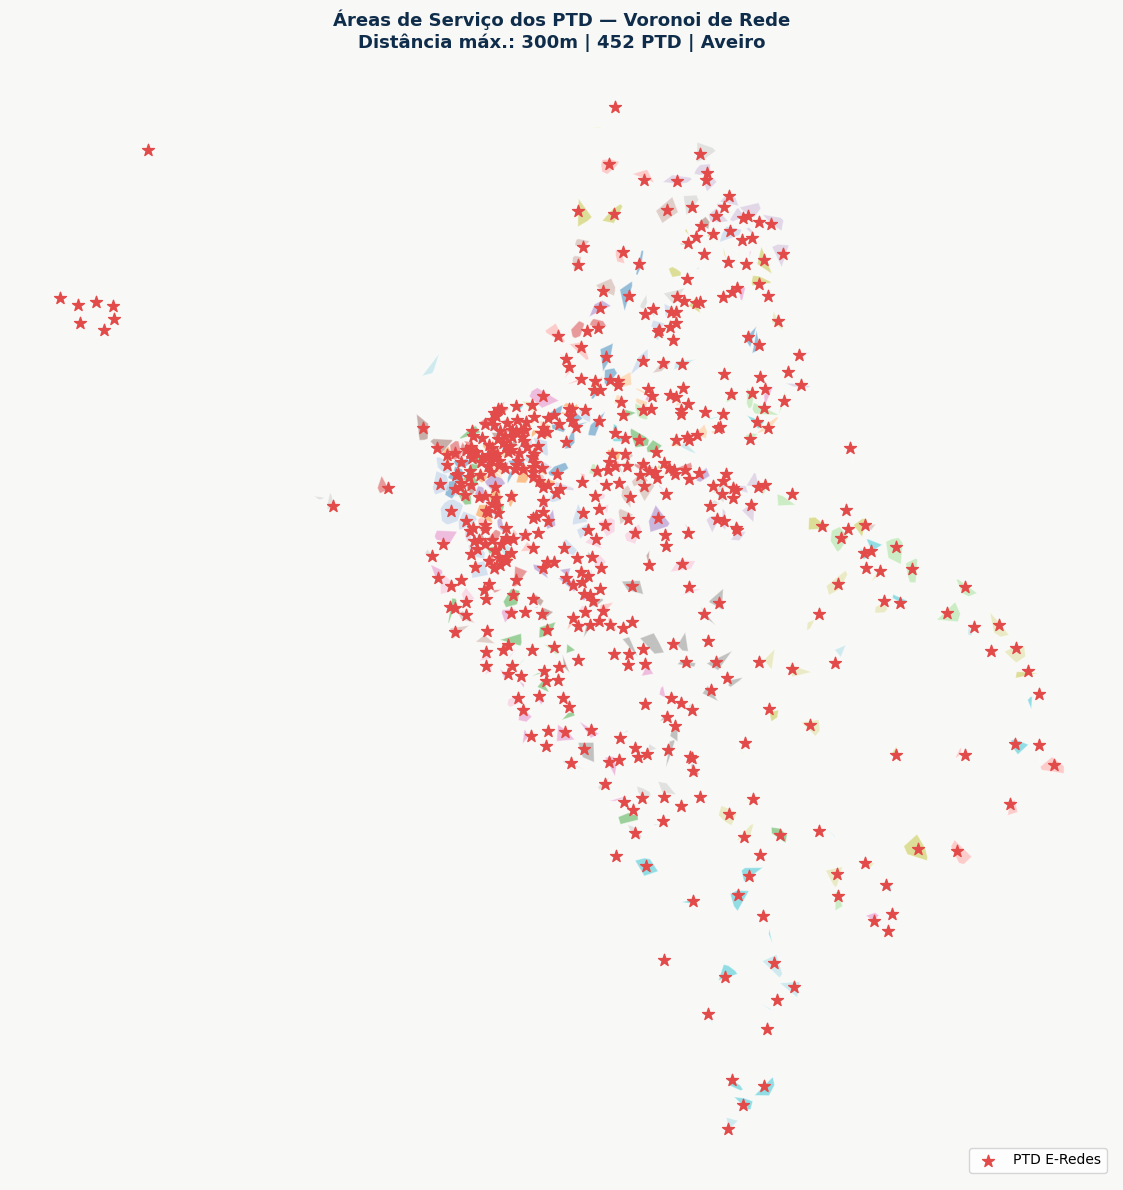

✓ Mapa guardado → mapa_voronoi_rede_PTD.png


In [28]:
# ─────────────────────────────────────────────────────────────
# BLOCO 9 — Visualização estática (matplotlib)
# ─────────────────────────────────────────────────────────────

print("\nA gerar mapa das áreas de serviço...")

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('#F8F8F6')
ax.set_facecolor('#F8F8F6')

# Gerar cores distintas por PTD
n_ptds  = len(gdf_areas)
cmap    = plt.cm.get_cmap('tab20', n_ptds)
cores   = [mcolors.to_hex(cmap(i)) for i in range(n_ptds)]

# Desenhar cada área de serviço com cor distinta
for i, (_, row) in enumerate(gdf_areas.iterrows()):
    gpd.GeoDataFrame([row], crs=CRS_METRICO).plot(
        ax=ax,
        color=cores[i % len(cores)],
        alpha=0.45,
        edgecolor='white',
        linewidth=0.8
    )

# Desenhar os PTD como estrelas vermelhas
gdf_ptd_metro.plot(
    ax=ax,
    color='#E24B4A',
    markersize=80,
    marker='*',
    zorder=5,
    label='PTD E-Redes'
)

# Anotações dos PTD (opcional — pode ficar sobrelotado com muitos PTD)
# for _, row in gdf_ptd_metro.iterrows():
#     ax.annotate(str(row[COL_ID_PTD]),
#                 xy=(row.geometry.x, row.geometry.y),
#                 fontsize=6, color='black', ha='center')

plt.title(
    f'Áreas de Serviço dos PTD — Voronoi de Rede\n'
    f'Distância máx.: {DISTANCIA_MAX_M}m | {len(gdf_areas)} PTD | Aveiro',
    fontsize=13, fontweight='bold', color='#0F2D4A'
)
plt.axis('off')
plt.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(CAMINHO_OUTPUT + 'mapa_voronoi_rede_PTD.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Mapa guardado → mapa_voronoi_rede_PTD.png")

In [29]:

# BLOCO 10 — Visualização interativa (Folium)

print("\nA gerar mapa interativo...")
import folium
import branca.colormap as cm

# Centro do mapa
centro_lat = gdf_ptd_wgs84.geometry.y.mean()
centro_lon = gdf_ptd_wgs84.geometry.x.mean()

m = folium.Map(
    location=[centro_lat, centro_lon],
    zoom_start=13,
    tiles='CartoDB positron'
)

# Converter áreas para WGS84 para o Folium
gdf_areas_wgs = gdf_areas.to_crs("EPSG:4326")

# Desenhar áreas de serviço
for i, (_, row) in enumerate(gdf_areas_wgs.iterrows()):
    if row.geometry is None or row.geometry.is_empty:
        continue
    cor = cores[i % len(cores)]
    folium.GeoJson(
        data=gpd.GeoDataFrame([row], crs="EPSG:4326").__geo_interface__,
        style_function=lambda x, c=cor: {
            'fillColor'  : c,
            'color'      : '#ffffff',
            'weight'     : 1,
            'fillOpacity': 0.45
        },
        tooltip=folium.GeoJsonTooltip(
            fields=['ptd_id', 'n_nos', 'area_km2'],
            aliases=['PTD ID:', 'Nós da rede:', 'Área (km²):'],
            style="font-size:12px;"
        )
    ).add_to(m)

# Desenhar PTD como marcadores
for _, row in gdf_ptd_wgs84.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        tooltip=f"PTD: {row[COL_ID_PTD] if COL_ID_PTD in row else 'N/A'}",
        icon=folium.Icon(color='red', icon='bolt', prefix='fa')
    ).add_to(m)

folium.LayerControl().add_to(m)
m.save(CAMINHO_OUTPUT + 'mapa_voronoi_rede_PTD.html')
print("✓ Mapa interativo guardado → mapa_voronoi_rede_PTD.html")


A gerar mapa interativo...
✓ Mapa interativo guardado → mapa_voronoi_rede_PTD.html


In [ ]:
"""
Voronoi de Rede — Áreas de Influência dos PTD usando Ruas
Projeto CER Aveiro

Calcula as áreas de serviço de cada Posto de Transformação de Distribuição (PTD)
usando a rede de ruas real em vez de distância euclidiana (Voronoi geométrico).

Bibliotecas necessárias:
    pip install osmnx networkx geopandas shapely matplotlib folium scipy
"""




# ─────────────────────────────────────────────────────────────
# BLOCO 11 — Validação: comparar Voronoi de rede vs Euclidiano
# ─────────────────────────────────────────────────────────────

print("\nA calcular Voronoi Euclidiano para comparação...")

from scipy.spatial import Voronoi as ScipyVoronoi
from shapely.ops import voronoi_diagram as shapely_voronoi

# Voronoi euclidiano com Shapely
pontos_ptd  = MultiPoint([row.geometry for _, row in gdf_ptd_metro.iterrows()])
regiao_total = gdf_areas.unary_union.convex_hull.buffer(500)

vor_euclid   = shapely_voronoi(pontos_ptd, envelope=regiao_total)
gdf_vor_euclid = gpd.GeoDataFrame(
    geometry=list(vor_euclid.geoms),
    crs=CRS_METRICO
)

# Comparação visual lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#F8F8F6')

# Voronoi euclidiano
for i, (_, row) in enumerate(gdf_vor_euclid.iterrows()):
    gpd.GeoDataFrame([row], crs=CRS_METRICO).plot(
        ax=axes[0], color=cores[i % len(cores)], alpha=0.5,
        edgecolor='white', linewidth=0.8
    )
gdf_ptd_metro.plot(ax=axes[0], color='red', markersize=60, marker='*', zorder=5)
axes[0].set_title('Voronoi Euclidiano\n(distância em linha reta)', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Voronoi de rede
for i, (_, row) in enumerate(gdf_areas.iterrows()):
    gpd.GeoDataFrame([row], crs=CRS_METRICO).plot(
        ax=axes[1], color=cores[i % len(cores)], alpha=0.5,
        edgecolor='white', linewidth=0.8
    )
gdf_ptd_metro.plot(ax=axes[1], color='red', markersize=60, marker='*', zorder=5)
axes[1].set_title(f'Voronoi de Rede (este trabalho)\n(distância pelas ruas, raio {DISTANCIA_MAX_M}m)',
                  fontsize=12, fontweight='bold', color='#0D9488')
axes[1].axis('off')

plt.suptitle('Comparação: Voronoi Euclidiano vs Voronoi de Rede',
             fontsize=14, fontweight='bold', color='#0F2D4A')
plt.tight_layout()
plt.savefig(CAMINHO_OUTPUT + 'comparacao_voronoi_euclid_vs_rede.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Comparação guardada → comparacao_voronoi_euclid_vs_rede.png")

print("\n" + "="*55)
print("  Pipeline Voronoi de Rede concluído!")
print("="*55)
print(f"  Ficheiros gerados em: {CAMINHO_OUTPUT}")
print("  - PTD_Areas_Servico_Rede.gpkg      (áreas de serviço)")
print("  - Edificios_com_PTD_Rede.gpkg      (edifícios + PTD atribuído)")
print("  - mapa_voronoi_rede_PTD.png        (mapa estático)")
print("  - mapa_voronoi_rede_PTD.html       (mapa interativo)")
print("  - comparacao_voronoi_euclid_vs_rede.png")


A calcular Voronoi Euclidiano para comparação...
